<p><font size="6" color='grey'> <b>
KI-Agenten. Verstehen. Anwenden. Gestalten.
</b></font> </br></p>

<font size="5" color='grey'> <b>
M26 | Advanced RAG – Pipeline-Patterns &nbsp;|&nbsp; ⭐ Vertiefung
</b></font> </br>

---

In [ ]:
#@title 🔧 Umgebung einrichten{ display-mode: "form" }
!uv pip install --system -q git+https://github.com/ralf-42/Agenten.git#subdirectory=04_modul

import os
os.environ["LANGSMITH_TRACING"]  = "true"
os.environ["LANGSMITH_PROJECT"]  = "M26-Advanced-RAG"
os.environ["LANGSMITH_ENDPOINT"] = "https://eu.api.smith.langchain.com"

from genai_lib.utilities import (
    check_environment,
    get_ipinfo,
    setup_api_keys,
    mprint,
    install_packages,
    mermaid,
    load_prompt,
    show_trace
)
setup_api_keys(['OPENAI_API_KEY', 'LANGSMITH_API_KEY'], create_globals=False)
print()
check_environment()
print()
get_ipinfo()

✓ OPENAI_API_KEY erfolgreich gesetzt
✓ LANGSMITH_API_KEY erfolgreich gesetzt

Python Version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]

Installierte LangChain- und LangGraph-Bibliotheken:
langchain                                1.2.10
langchain-chroma                         1.1.0
langchain-classic                        1.0.1
langchain-community                      0.4.1
langchain-core                           1.2.16
langchain-ollama                         1.0.1
langchain-openai                         1.1.10
langchain-text-splitters                 1.1.1
langgraph                                1.0.9
langgraph-checkpoint                     4.0.0
langgraph-prebuilt                       1.0.8
langgraph-sdk                            0.3.9

IP-Adresse: 136.109.85.15
Hostname: 15.85.109.136.bc.googleusercontent.com
Stadt: The Dalles
Region: Oregon
Land: US
Koordinaten: 45.5946,-121.1787
Provider: AS396982 Google LLC
Postleitzahl: 97058
Zeitzone: America/Los_Angeles


In [ ]:
#@title 🛠️ Installationen { display-mode: "form" }
install_packages([
    ('markitdown[all]', 'markitdown'),
])

🔄 Installiere markitdown[all]...
✅ markitdown[all] erfolgreich installiert und importiert


In [ ]:
#@title 📂 Dokumente, Bilder { display-mode: "form" }
!rm -rf files
!mkdir files
!curl -L https://raw.githubusercontent.com/ralf-42/Agenten/main/02_daten/01_text/biografien_1.txt -o files/biografien_1.txt
!curl -L https://raw.githubusercontent.com/ralf-42/Agenten/main/02_daten/01_text/biografien_2.md -o files/biografien_2.md
!curl -L https://raw.githubusercontent.com/ralf-42/Agenten/main/02_daten/01_text/biografien_3.pdf -o files/biografien_3.pdf
!curl -L https://raw.githubusercontent.com/ralf-42/Agenten/main/02_daten/01_text/biografien_4.docx -o files/biografien_4.docx

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  5324  100  5324    0     0  23009      0 --:--:-- --:--:-- --:--:-- 23047
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  7868  100  7868    0     0  36404      0 --:--:-- --:--:-- --:--:-- 36425
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 68184  100 68184    0     0   282k      0 --:--:-- --:--:-- --:--:--  283k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 18743  100 18743    0     0  81216      0 --:--:-- --:--:-- --:--:-- 81491


# 1 | Von Basic zu Advanced RAG
---

> ⭐ **Vertiefungsmodul** — Dieses Modul ist optional.
> Pflicht-Lernpfad: M08–M11 (RAG Grundlagen) → **M23** (Pipeline & Agentic RAG – Überblick) → **M26** (Advanced RAG Pipeline-Patterns – Vertiefung).
> Empfohlen wenn: RAG-Qualität in eigenen Projekten verbessert werden soll.

<p><font color='black' size='5'>
Motivation
</font></p>

Im Modul **M08** haben Sie die Grundlagen von RAG (Retrieval-Augmented Generation) kennengelernt:

```
User Query → Retrieve Documents → Generate Answer
```

**Das funktioniert gut, aber es gibt Probleme:**

❌ **Problem 1: Irrelevante Dokumente**
- Der Retriever findet manchmal unpassende Dokumente
- Diese verwirren das LLM und führen zu schlechten Antworten

❌ **Problem 2: Halluzinationen**
- Das LLM erfindet Fakten, die nicht in den Dokumenten stehen
- Keine Überprüfung der generierten Antwort

❌ **Problem 3: Unflexibel**
- Der Workflow ist statisch: Immer retrieve → generate
- Keine Anpassung an die Qualität der Zwischenergebnisse

**Lösung: Advanced RAG mit LangGraph!**

✅ **Self-RAG:** Bewertet gefundene Dokumente vor der Generierung    
✅ **Corrective RAG:** Verbessert Queries bei schlechten Ergebnissen   
✅ **Adaptive RAG:** Passt den Workflow dynamisch an   

<p><font color='black' size='5'>
Übersicht der Patterns
</font></p>

| Pattern | Was macht es? | Wann verwenden? |
|---------|---------------|------------------|
| **Self-RAG** | Bewertet Relevanz der Dokumente | Wenn Retrieval-Qualität wichtig ist |
| **Reranking** | Sortiert Docs nach Relevanz-Score | Wenn Reihenfolge der Docs wichtig ist |
| **Corrective RAG** | Verbessert Query bei schlechten Retrievals | Wenn Nutzer-Queries ungenau sind |
| **Adaptive RAG** | Wählt beste Strategie basierend auf Query-Typ | Für vielseitige Anwendungen |

**In diesem Modul bauen wir:**
1. Self-RAG mit Document Grading
2. Reranking: Dokumente nach Relevanz-Score sortieren
3. Corrective RAG mit Query Rewriting
4. Adaptive RAG mit Routing Logic

# 2 | Setup & Vorbereitung
---

In [ ]:
# Imports
from typing import TypedDict, List
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from pydantic import BaseModel, Field

# LangGraph
from langgraph.graph import StateGraph, START, END

In [ ]:
# Modell und Embeddings
llm = init_chat_model("openai:gpt-4o-mini", temperature=0.0)
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

print("✅ LLM und Embeddings initialisiert")

✅ LLM und Embeddings initialisiert


<p><font color='black' size='5'>
Dokumente aus Dateien laden
</font></p>

Wir laden die Biografien-Dateien und erstellen daraus eine Wissensbasis.

In [ ]:
# Document Loaders importieren
from markitdown import MarkItDown
from langchain_text_splitters import RecursiveCharacterTextSplitter

# MarkItDown für verschiedene Dateiformate
md = MarkItDown()

# Dateien laden
import os
documents = []

files_dir = "./files"
for filename in os.listdir(files_dir):
    filepath = os.path.join(files_dir, filename)
    if os.path.isfile(filepath):
        try:
            # Konvertierung zu Markdown
            result = md.convert(filepath)
            content = result.text_content

            # Document erstellen
            doc = Document(
                page_content=content,
                metadata={"source": filename}
            )
            documents.append(doc)
            print(f"✅ Geladen: {filename}")
        except Exception as e:
            print(f"⚠️ Fehler bei {filename}: {e}")

# Text Splitting
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)
split_docs = text_splitter.split_documents(documents)

print(f"\n📄 {len(documents)} Dateien geladen")
print(f"📦 {len(split_docs)} Chunks erstellt")

# Vektordatenbank erstellen
vectorstore = Chroma.from_documents(
    documents=split_docs,
    embedding=embeddings,
    collection_name="advanced_rag_biografien"
)

# Retriever erstellen
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

print(f"✅ Vektordatenbank mit {len(split_docs)} Chunks erstellt")

✅ Geladen: biografien_3.pdf
✅ Geladen: biografien_4.docx
✅ Geladen: biografien_1.txt
✅ Geladen: biografien_2.md

📄 4 Dateien geladen
📦 51 Chunks erstellt
✅ Vektordatenbank mit 51 Chunks erstellt


# 3 | Self-RAG: Document Grading
---

<p><font color='black' size='5'>
Konzept
</font></p>

**Self-RAG fügt einen Bewertungsschritt hinzu:**

```
Query → Retrieve → [GRADE DOCS] → Generate (nur mit relevanten Docs)
```

**Warum wichtig?**
- Irrelevante Dokumente werden herausgefiltert
- Das LLM bekommt nur hochwertige Informationen
- Reduziert Halluzinationen und verbessert Genauigkeit

<p><font color='black' size='5'>
State Definition
</font></p>

In [ ]:
class SelfRAGState(TypedDict):
    """State für Self-RAG Workflow"""
    query: str                          # Nutzer-Anfrage
    documents: List[Document]           # Abgerufene Dokumente
    relevant_documents: List[Document]  # Gefilterte relevante Dokumente
    answer: str                         # Generierte Antwort
    relevance_scores: List[str]         # "yes"/"no" für jedes Dokument

<p><font color='black' size='5'>
Document Grader mit structured output
</font></p>

In [ ]:
# Pydantic-Modell für Bewertung
class GradeDocuments(BaseModel):
    """Bewertet ob ein Dokument relevant für die Query ist"""
    score: str = Field(
        description="'yes' wenn relevant, 'no' wenn nicht relevant"
    )

# Strukturiertes LLM für Grading
grader_llm = llm.with_structured_output(GradeDocuments)

# Grading Prompt – streng: nur direkte Relevanz zählt
grade_prompt = ChatPromptTemplate.from_messages([
    ("system", """Du bist ein strenger Relevanz-Bewerter.
Gib NUR 'yes' zurück wenn das Dokument DIREKTE Informationen zur Beantwortung enthält.
Gib 'no' zurück wenn:
- Das Dokument nur vage verwandt ist
- Die Anfrage zu unklar oder vage für dieses Dokument ist
- Keine konkreten Fakten zur Anfrage vorhanden sind"""),
    ("human", """Dokument:
{document}

Benutzeranfrage: {query}

Ist dieses Dokument direkt relevant?""")
])

# Grading Chain
grader_chain = grade_prompt | grader_llm

print("✅ Document Grader erstellt (strenger Modus)")

✅ Document Grader erstellt (strenger Modus)


<p><font color='black' size='5'>
Graph Nodes definieren
</font></p>

In [ ]:
def retrieve_node(state: SelfRAGState) -> SelfRAGState:
    """Ruft Dokumente ab"""
    query = state["query"]
    documents = retriever.invoke(query)
    print(f"🔍 Retrieved {len(documents)} Dokumente")
    return {"documents": documents}

def grade_documents_node(state: SelfRAGState) -> SelfRAGState:
    """Bewertet jedes Dokument auf Relevanz"""
    query = state["query"]
    documents = state["documents"]

    relevant_docs = []
    scores = []

    for doc in documents:
        # Dokument bewerten
        grade = grader_chain.invoke({
            "document": doc.page_content,
            "query": query
        })

        scores.append(grade.score)

        if grade.score == "yes":
            relevant_docs.append(doc)
            print(f"✅ Relevant: {doc.page_content[:50]}...")
        else:
            print(f"❌ Nicht relevant: {doc.page_content[:50]}...")

    print(f"\n📊 {len(relevant_docs)}/{len(documents)} Dokumente relevant")

    return {
        "relevant_documents": relevant_docs,
        "relevance_scores": scores
    }

def generate_node(state: SelfRAGState) -> SelfRAGState:
    """Generiert Antwort basierend auf relevanten Dokumenten"""
    query = state["query"]
    docs = state["relevant_documents"]

    # Kontext zusammenstellen
    context = "\n\n".join([doc.page_content for doc in docs])

    # RAG Prompt
    rag_prompt = ChatPromptTemplate.from_messages([
        ("system", "Du bist ein hilfreicher Assistent. Beantworte die Frage basierend auf dem Kontext."),
        ("human", """Kontext:
{context}

Frage: {query}

Antwort:""")
    ])

    # Generierung
    chain = rag_prompt | llm | StrOutputParser()
    answer = chain.invoke({"context": context, "query": query})

    print(f"\n🤖 Antwort generiert ({len(answer)} Zeichen)")

    return {"answer": answer}

print("✅ Nodes definiert")

✅ Nodes definiert


<p><font color='black' size='5'>
Graph aufbauen
</font></p>

In [ ]:
# Self-RAG Workflow erstellen
self_rag_workflow = StateGraph(SelfRAGState)

# Nodes hinzufügen
self_rag_workflow.add_node("retrieve", retrieve_node)
self_rag_workflow.add_node("grade_documents", grade_documents_node)
self_rag_workflow.add_node("generate", generate_node)

# Edges definieren
self_rag_workflow.add_edge(START, "retrieve")
self_rag_workflow.add_edge("retrieve", "grade_documents")
self_rag_workflow.add_edge("grade_documents", "generate")
self_rag_workflow.add_edge("generate", END)

# Graph kompilieren
self_rag_app = self_rag_workflow.compile()

print("✅ Self-RAG Graph kompiliert")

✅ Self-RAG Graph kompiliert


<p><font color='black' size='5'>
Graph Visualisierung
</font></p>

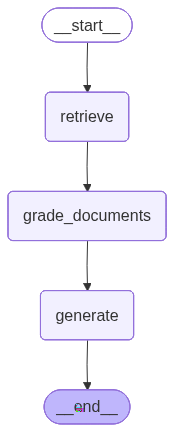

In [ ]:
from IPython.display import Image, display

try:
    display(Image(self_rag_app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"⚠️ Graph-Visualisierung nicht verfügbar: {e}")

<p><font color='black' size='5'>
Self-RAG testen
</font></p>

In [ ]:
# Test Query
test_query = "Wer war Alan Turing und was hat er erforscht?"

# Workflow ausführen
result = self_rag_app.invoke({
    "query": test_query
})

# Ergebnis anzeigen
mprint("## 🎯 Self-RAG Ergebnis")
mprint("---")
mprint(f"**Query:** {test_query}")
mprint(f"**Antwort:** {result['answer']}")

🔍 Retrieved 3 Dokumente
❌ Nicht relevant: antiken Artefakten und Computern auf. Er ist ein p...
❌ Nicht relevant: Kazuki Tanaka: Kazuki Tanaka ist ein Gedächtnisarc...
❌ Nicht relevant: Oliver Jensen: Oliver Jensen ist ein Archäoinforma...

📊 0/3 Dokumente relevant

🤖 Antwort generiert (992 Zeichen)


## 🎯 Self-RAG Ergebnis

---

**Query:** Wer war Alan Turing und was hat er erforscht?

**Antwort:** Alan Turing war ein britischer Mathematiker, Logiker, Informatiker und Kryptoanalytiker, der als einer der Väter der modernen Informatik gilt. Er wurde 1912 geboren und ist bekannt für seine Arbeiten zur theoretischen Informatik, insbesondere für das Konzept der Turing-Maschine, ein fundamentales Modell für die Berechnung und die Theorie der Algorithmen.

Turing spielte eine entscheidende Rolle während des Zweiten Weltkriegs, als er an der Entschlüsselung der Enigma-Verschlüsselung arbeitete, die von den deutschen Streitkräften verwendet wurde. Seine Arbeit trug maßgeblich dazu bei, den Krieg zu verkürzen und viele Leben zu retten. Darüber hinaus forschte Turing auch in den Bereichen künstliche Intelligenz und mathematische Logik. Sein berühmtes Turing-Test-Konzept wird oft als Maßstab für die Fähigkeit einer Maschine angesehen, menschenähnliches Denken zu simulieren. Turing starb 1954 und wurde posthum für seine bedeutenden Beiträge zur Wissenschaft und Gesellschaft anerkannt.

# 4 | Reranking: Dokumente neu ordnen
---

<p><font color='black' size='5'>
Konzept
</font></p>

**Vektor-Similarity ist ein schnelles, aber grobes Relevanz-Mass.**
Die Top-K Dokumente sind nach Cosine-Ähnlichkeit sortiert –
das muss nicht die beste Reihenfolge für die Antwort sein.

**Reranking** bewertet die abgerufenen Dokumente ein zweites Mal,
präziser und kontextbezogener:

```
Query → Retrieve (k=10) → [RERANK] → Top-3 → Generate
```

| Schritt | Methode | Geschwindigkeit | Genauigkeit |
|---------|---------|----------------|-------------|
| Retrieval | Cosine-Similarity | ✅ Sehr schnell | ⚠️ Grob |
| Reranking | CrossEncoder / LLM | ⚠️ Langsamer | ✅ Präzise |

**Zwei Ansätze:**
- **LLM-Reranker:** Gibt Relevanz-Score 0–10, keine zusätzlichen Pakete
- **CrossEncoder:** HuggingFace-Modell, schneller als LLM, sehr präzise

Wir implementieren den **LLM-Reranker** (einfach, direkt nutzbar).

In [ ]:
#@title
#@markdown   <p><font size="4" color='green'>  flowchart: RAG mit Reranking</font> </br></p>

diagram = '''
flowchart LR
    Q[/Query/] --> RET["Retrieve\nk=6 Docs"]
    RET --> RR["Reranker\nScore 0-10"]
    RR --> TOP["Top-3\n(höchste Scores)"]
    TOP --> GEN[Generate]
    GEN --> ANT[/Antwort/]

    subgraph STANDARD["Standard RAG"]
        RET2["Retrieve k=3"] --> GEN2[Generate]
    end

    style RR  fill:#FF9800,color:#fff
    style TOP fill:#4CAF50,color:#fff
    style STANDARD fill:#F5F5F5
'''
mermaid(diagram, width=800)

<p><font color='black' size='5'>
LLM-Reranker implementieren
</font></p>

Der Reranker bewertet jedes Dokument mit einem Score von 0–10
und sortiert die Dokumente nach Relevanz.

In [ ]:
class RelevanzScore(BaseModel):
    """Bewertet die Relevanz eines Dokuments fuer eine Query."""
    score: int = Field(
        description="Relevanz-Score von 0 (irrelevant) bis 10 (perfekt relevant)",
        ge=0, le=10
    )
    begruendung: str = Field(description="Kurze Begruendung fuer den Score")

reranker_llm = llm.with_structured_output(RelevanzScore)

rerank_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "Du bewertest die Relevanz von Dokumenten fuer eine Suchanfrage.\n"
     "Score 0: Komplett irrelevant.\n"
     "Score 5: Teilweise relevant, aber lueckenhaft.\n"
     "Score 10: Direkt und vollstaendig relevant."),
    ("human",
     "Suchanfrage: {query}\n\nDokument:\n{document}\n\nRelevanz-Score (0-10):")
])

reranker_chain = rerank_prompt | reranker_llm

def rerank_documents(query: str, docs: list, top_k: int = 3) -> list:
    """Bewertet und sortiert Dokumente nach Relevanz-Score."""
    scored = []
    for doc in docs:
        result = reranker_chain.invoke({
            "query": query,
            "document": doc.page_content[:600]
        })
        scored.append((doc, result.score, result.begruendung))
        print(f"  Score {result.score}/10: {doc.page_content[:60]}...")

    scored.sort(key=lambda x: x[1], reverse=True)
    return [doc for doc, score, _ in scored[:top_k]], scored

print("Reranker definiert")

Reranker definiert


<p><font color='black' size='5'>
Reranking in Self-RAG integrieren
</font></p>

Wir erweitern die Self-RAG Pipeline um einen Reranking-Schritt
zwischen Retrieve und Grade:

In [ ]:
class RerankRAGState(TypedDict):
    query:              str
    documents:          List[Document]   # Initiales Retrieval (k=6)
    reranked_documents: List[Document]   # Nach Reranking (Top-3)
    relevant_documents: List[Document]   # Nach Grading
    answer:             str
    relevance_scores:   List[str]

# k=6 fuer mehr Kandidaten beim Reranking
retriever_wide = vectorstore.as_retriever(search_kwargs={"k": 6})

def retrieve_wide_node(state: RerankRAGState) -> dict:
    docs = retriever_wide.invoke(state["query"])
    print(f"Retrieved {len(docs)} Docs (wide)")
    return {"documents": docs}

def rerank_node(state: RerankRAGState) -> dict:
    """Rerankt die Dokumente und gibt Top-3 zurueck."""
    print(f"Reranking {len(state["documents"])} Dokumente...")
    top_docs, scored = rerank_documents(state["query"], state["documents"], top_k=3)
    print(f"Top-3 nach Reranking:")
    for doc, score, reason in scored[:3]:
        print(f"  {score}/10 | {reason[:60]}")
    return {"reranked_documents": top_docs}

def grade_reranked_node(state: RerankRAGState) -> dict:
    """Gradet nur die Top-3 reranked Dokumente."""
    query = state["query"]
    relevant_docs, scores = [], []
    for doc in state["reranked_documents"]:
        grade = grader_chain.invoke({"document": doc.page_content, "query": query})
        scores.append(grade.score)
        if grade.score == "yes":
            relevant_docs.append(doc)
    print(f"{len(relevant_docs)}/{len(state["reranked_documents"])} Docs nach Grading relevant")
    return {"relevant_documents": relevant_docs, "relevance_scores": scores}

def generate_rerank_node(state: RerankRAGState) -> dict:
    docs    = state["relevant_documents"]
    context = "\n\n".join([d.page_content for d in docs]) if docs else ""
    prompt  = ChatPromptTemplate.from_messages([
        ("system", "Beantworte die Frage auf Basis des Kontexts. Deutsch."),
        ("human",  "Kontext:\n{context}\n\nFrage: {query}")
    ])
    chain  = prompt | llm | StrOutputParser()
    answer = chain.invoke({"context": context, "query": state["query"]})
    return {"answer": answer}

print("Rerank-RAG Nodes definiert")

Rerank-RAG Nodes definiert


In [ ]:
rr_workflow = StateGraph(RerankRAGState)
rr_workflow.add_node("retrieve",  retrieve_wide_node)
rr_workflow.add_node("rerank",    rerank_node)
rr_workflow.add_node("grade",     grade_reranked_node)
rr_workflow.add_node("generate",  generate_rerank_node)

rr_workflow.add_edge(START,      "retrieve")
rr_workflow.add_edge("retrieve", "rerank")
rr_workflow.add_edge("rerank",   "grade")
rr_workflow.add_edge("grade",    "generate")
rr_workflow.add_edge("generate", END)

rerank_app = rr_workflow.compile()
print("Rerank-RAG Graph kompiliert")

try:
    display(Image(rerank_app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Graph-Visualisierung: {e}")

Rerank-RAG Graph kompiliert


<p><font color='black' size='5'>
Reranking testen
</font></p>

In [ ]:
query_rr = "Wer hat bahnbrechende wissenschaftliche Entdeckungen gemacht?"

mprint("## Reranking: Scoring der Kandidaten")
result_rr = rerank_app.invoke({"query": query_rr})

mprint("---")
mprint(f"**Query:** {query_rr}")
mprint(f"**Relevante Docs nach Reranking+Grading:** {len(result_rr['relevant_documents'])}")
mprint(f"**Antwort:** {result_rr['answer']}")

## Reranking: Scoring der Kandidaten

Retrieved 6 Docs (wide)
Reranking 6 Dokumente...
  Score 5/10: Soren Lindquist: Soren Lindquist ist ein Chronobiologe und
Z...
  Score 10/10: Chiara Lombardi: Chiara Lombardi ist eine Marine-Biotechnolo...
  Score 0/10: antiken Artefakten und Computern auf. Er ist ein passioniert...
  Score 5/10: # 10 Weitere Einzigartige Biografien

Linus Bergström: Linus...
  Score 5/10: Hiroshi Watanabe: Hiroshi Watanabe ist ein Quantenökologe un...
  Score 0/10: Hugo Zehnder: Hugo Zehnder ist ein professioneller Wolkenkün...
Top-3 nach Reranking:
  10/10 | Das Dokument beschreibt die bahnbrechenden wissenschaftliche
  5/10 | Das Dokument beschreibt die innovativen Methoden von Soren L
  5/10 | Das Dokument beschreibt eine Person mit einem interessanten 
3/3 Docs nach Grading relevant


---

**Query:** Wer hat bahnbrechende wissenschaftliche Entdeckungen gemacht?

**Relevante Docs nach Reranking+Grading:** 3

**Antwort:** Chiara Lombardi und Soren Lindquist haben beide bahnbrechende wissenschaftliche Entdeckungen gemacht. Chiara Lombardi hat ein innovatives System zur Gewinnung nachhaltiger Energie aus Tiefseehydrothermalen Quellen entwickelt, während Soren Lindquist revolutionäre Methoden zur Manipulation der subjektiven Zeitwahrnehmung erforscht hat. Auch Linus Bergström hat bedeutende Entdeckungen im Bereich der Glaziakustik und des Klimagedächtnisses gemacht.

# 5 | Corrective RAG: Query Rewriting
---

<p><font color='black' size='5'>
Konzept
</font></p>

**Corrective RAG (CRAG) erkennt schlechte Retrievals und reagiert:**

```
Query → Retrieve → Grade
                      ↓
            Gut? → Generate
                      ↓
         Schlecht? → Rewrite Query → Retrieve wieder
```

**Warum wichtig?**
- Nutzer-Queries sind oft ungenau oder missverständlich
- Durch Umformulierung werden bessere Dokumente gefunden
- Erhöht Erfolgsrate drastisch

<p><font color='black' size='5'>
State Definition
</font></p>

In [ ]:
class CRAGState(TypedDict):
    """State für Corrective RAG"""
    original_query: str           # Ursprüngliche Query
    query: str                    # Aktuelle Query (kann umgeschrieben sein)
    documents: List[Document]
    relevant_documents: List[Document]
    answer: str
    retry_count: int              # Wie oft wurde umgeschrieben?
    has_relevant_docs: bool       # Flag für Routing

<p><font color='black' size='5'>
Query Rewriter
</font></p>

In [ ]:
# Query Rewriting Prompt
rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system", "Du bist ein Experte für das Umformulieren von Suchanfragen."),
    ("human", """Die folgende Suchanfrage hat keine guten Ergebnisse geliefert.
Formuliere sie um, um bessere Dokumente zu finden.
Mache sie spezifischer und nutze Synonyme.

Ursprüngliche Query: {query}

Verbesserte Query:""")
])

# Rewriting Chain
rewriter_chain = rewrite_prompt | llm | StrOutputParser()

print("✅ Query Rewriter erstellt")

✅ Query Rewriter erstellt


<p><font color='black' size='5'>
CRAG Nodes
</font></p>

In [ ]:
def crag_retrieve_node(state: CRAGState) -> CRAGState:
    """Retrieval für CRAG"""
    query = state["query"]
    documents = retriever.invoke(query)
    print(f"🔍 Retrieved {len(documents)} Dokumente für Query: '{query}'")
    return {"documents": documents}

def crag_grade_node(state: CRAGState) -> CRAGState:
    """Grading für CRAG mit Entscheidungslogik"""
    query = state["query"]
    documents = state["documents"]

    relevant_docs = []

    for doc in documents:
        grade = grader_chain.invoke({
            "document": doc.page_content,
            "query": query
        })

        if grade.score == "yes":
            relevant_docs.append(doc)

    # Entscheidung: Gibt es genug relevante Dokumente?
    has_relevant = len(relevant_docs) > 0

    if has_relevant:
        print(f"✅ {len(relevant_docs)} relevante Dokumente gefunden")
    else:
        print(f"❌ Keine relevanten Dokumente → Query wird umgeschrieben")

    return {
        "relevant_documents": relevant_docs,
        "has_relevant_docs": has_relevant
    }

def rewrite_query_node(state: CRAGState) -> CRAGState:
    """Schreibt Query um"""
    original = state["original_query"]
    current = state["query"]
    retry = state.get("retry_count", 0)

    # Query umschreiben
    new_query = rewriter_chain.invoke({"query": current})

    print(f"🔄 Query umgeschrieben (Versuch {retry + 1})")
    print(f"   Alt: '{current}'")
    print(f"   Neu: '{new_query}'")

    return {
        "query": new_query,
        "retry_count": retry + 1
    }

def crag_generate_node(state: CRAGState) -> CRAGState:
    """Generierung für CRAG"""
    query = state["original_query"]  # Verwende ursprüngliche Query für Antwort
    docs = state["relevant_documents"]

    context = "\n\n".join([doc.page_content for doc in docs])

    rag_prompt = ChatPromptTemplate.from_messages([
        ("system", "Du bist ein hilfreicher Assistent."),
        ("human", "Kontext:\n{context}\n\nFrage: {query}\n\nAntwort:")
    ])

    chain = rag_prompt | llm | StrOutputParser()
    answer = chain.invoke({"context": context, "query": query})

    return {"answer": answer}

print("✅ CRAG Nodes definiert")

✅ CRAG Nodes definiert


<p><font color='black' size='5'>
CRAG Graph mit Conditional Routing
</font></p>

In [ ]:
# Routing Funktion
def route_after_grading(state: CRAGState) -> str:
    """Entscheidet: Generate oder Rewrite?"""
    retry_count = state.get("retry_count", 0)
    has_relevant = state["has_relevant_docs"]

    # Maximal 2 Rewrite-Versuche
    if has_relevant or retry_count >= 2:
        return "generate"
    else:
        return "rewrite_query"

# CRAG Workflow
crag_workflow = StateGraph(CRAGState)

# Nodes
crag_workflow.add_node("retrieve", crag_retrieve_node)
crag_workflow.add_node("grade", crag_grade_node)
crag_workflow.add_node("rewrite_query", rewrite_query_node)
crag_workflow.add_node("generate", crag_generate_node)

# Edges
crag_workflow.add_edge(START, "retrieve")
crag_workflow.add_edge("retrieve", "grade")

# Conditional Edge: Nach Grading
crag_workflow.add_conditional_edges(
    "grade",
    route_after_grading,
    {
        "generate": "generate",
        "rewrite_query": "rewrite_query"
    }
)

# Nach Rewrite wieder zu Retrieve
crag_workflow.add_edge("rewrite_query", "retrieve")
crag_workflow.add_edge("generate", END)

# Kompilieren
crag_app = crag_workflow.compile()

print("✅ CRAG Graph mit Conditional Routing kompiliert")

✅ CRAG Graph mit Conditional Routing kompiliert


<p><font color='black' size='5'>
CRAG Graph Visualisierung
</font></p>

In [ ]:
try:
    display(Image(crag_app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"⚠️ Graph-Visualisierung nicht verfügbar: {e}")

<p><font color='black' size='5'>
CRAG testen
</font></p>

In [ ]:
# Test mit einer Query, die nicht im Datensatz ist → Rewrite soll auslösen
test_query = "Was hat Schrödingers Katze mit Quantencomputern zu tun?"

result = crag_app.invoke({
    "original_query": test_query,
    "query": test_query,
    "retry_count": 0
})

mprint("## 🎯 CRAG Ergebnis")
mprint("---")
mprint(f"**Ursprüngliche Query:** {result['original_query']}")
mprint(f"**Finale Query:** {result['query']}")
mprint(f"**Rewrite-Versuche:** {result.get('retry_count', 0)}")
mprint(f"**Antwort:** {result['answer']}")

🔍 Retrieved 3 Dokumente für Query: 'Was hat Schrödingers Katze mit Quantencomputern zu tun?'
❌ Keine relevanten Dokumente → Query wird umgeschrieben
🔄 Query umgeschrieben (Versuch 1)
   Alt: 'Was hat Schrödingers Katze mit Quantencomputern zu tun?'
   Neu: 'Wie hängt das Gedankenexperiment von Schrödingers Katze mit der Funktionsweise von Quantencomputern zusammen?'
🔍 Retrieved 3 Dokumente für Query: 'Wie hängt das Gedankenexperiment von Schrödingers Katze mit der Funktionsweise von Quantencomputern zusammen?'
❌ Keine relevanten Dokumente → Query wird umgeschrieben
🔄 Query umgeschrieben (Versuch 2)
   Alt: 'Wie hängt das Gedankenexperiment von Schrödingers Katze mit der Funktionsweise von Quantencomputern zusammen?'
   Neu: 'Wie steht das Gedankenexperiment von Schrödingers Katze im Zusammenhang mit der Funktionsweise von Quantencomputern und deren quantenmechanischen Prinzipien?'
🔍 Retrieved 3 Dokumente für Query: 'Wie steht das Gedankenexperiment von Schrödingers Katze im Zusammenhan

## 🎯 CRAG Ergebnis

---

**Ursprüngliche Query:** Was hat Schrödingers Katze mit Quantencomputern zu tun?

**Finale Query:** Wie steht das Gedankenexperiment von Schrödingers Katze im Zusammenhang mit der Funktionsweise von Quantencomputern und deren quantenmechanischen Prinzipien?

**Rewrite-Versuche:** 2

**Antwort:** Schrödingers Katze ist ein berühmtes Gedankenexperiment, das von dem Physiker Erwin Schrödinger im Jahr 1935 formuliert wurde, um die Prinzipien der Quantenmechanik zu veranschaulichen, insbesondere das Konzept der Überlagerung. In diesem Experiment wird eine Katze in eine Kiste mit einem radioaktiven Atom, einem Geigerzähler und einem Giftbehälter gesetzt. Wenn das Atom zerfällt, wird der Geigerzähler aktiv, der Giftbehälter zerbricht und die Katze stirbt. Solange die Kiste geschlossen bleibt, ist die Katze sowohl lebendig als auch tot – sie befindet sich in einem Überlagerungszustand.

Die Verbindung zu Quantencomputern liegt in der Art und Weise, wie Quantenbits (Qubits) funktionieren. Während klassische Bits entweder den Wert 0 oder 1 haben, können Qubits durch Überlagerung gleichzeitig in beiden Zuständen sein. Dies ermöglicht Quantencomputern, viele Berechnungen parallel durchzuführen und Probleme viel schneller zu lösen als klassische Computer.

Zusammengefasst zeigt Schrödingers Katze, wie Quantenmechanik und Überlagerung funktionieren, was die Grundlage für die Funktionsweise von Quantencomputern bildet. Die Prinzipien, die in diesem Gedankenexperiment dargestellt werden, sind entscheidend für das Verständnis der Quantenverarbeitung und der Möglichkeiten, die sie bietet.

# 6 | Vergleich: Basic vs. Advanced RAG
---

| Aspekt | Basic RAG (M08) | Self-RAG | Corrective RAG | Reranking |
|--------|-----------------|----------|----------------|
| **Workflow** | Linear | Mit Grading | Mit Retry-Loop | Retrieve+Score+Sort |
| **Dokument-Qualität** | Nicht geprüft | ✅ Geprüft | ✅ Geprüft | ✅ Geprüft+Sortiert |
| **Query-Verbesserung** | ❌ Nein | ❌ Nein | ✅ Ja | ❌ Nein |
| **Anpassungsfähig** | ❌ Statisch | ⚠️ Teilweise | ✅ Dynamisch | ❌ Statisch |
| **Komplexität** | Niedrig | Mittel | Hoch | Mittel |
| **Reranking** | ❌ Nein | ❌ Nein | ❌ Nein | ✅ Ja |
| **Use Case** | Einfache Q&A | Qualitätskritisch | Unklare Queries | Mischung |


**Empfehlung:**
- **Basic RAG:** Für Prototyping und klare Use Cases
- **Self-RAG:** Wenn Retrieval-Qualität wichtig ist
- **Corrective RAG:** Wenn Nutzer-Queries ungenau sind

# 7 | Best Practices & Tipps
---

<p><font color='black' size='5'>
Performance-Optimierung
</font></p>

**Grading ist teuer (LLM-Calls):**
- ✅ Cache Grading-Ergebnisse für identische Dokumente
- ✅ Paralleles Grading mit `asyncio` (für große Dokumentenmengen)
- ✅ Alternative: Lightweight Relevance Scorer (z.B. Cosine-Similarity-Threshold)

**Rewriting Limits:**
- ✅ Maximal 2-3 Rewrite-Versuche (sonst zu langsam)
- ✅ Fallback: Web-Search wenn kein Doc gefunden wird

**Monitoring:**
- ✅ Logge Rewrite-Rate (zu hoch → Retrieval-Problem)
- ✅ Tracke Relevance-Scores (zu niedrig → Daten-Problem)

<p><font color='black' size='5'>
Wann welches Pattern?
</font></p>

| Szenario | Empfohlenes Pattern |
|----------|---------------------|
| **Hohe Datenqualität, klare Queries** | Basic RAG |
| **Viele irrelevante Retrieval-Ergebnisse** | Self-RAG |
| **Nutzer mit ungenauen Fragen** | Corrective RAG |
| **Kritische Anwendung (Legal, Medical)** | Self-RAG + Hallucination Check |
| **Niedrige Latenz wichtig** | Basic RAG (schneller) |
| **Hohe Accuracy wichtig** | Corrective RAG (besser) |

In [ ]:
#@title
#@markdown   <p><font size="4" color='green'>  LangSmith Trace-Analyse</font> </br></p>

import time as _t; _t.sleep(2)
show_trace("M26-Advanced-RAG", limit=3, show_steps=True)

# A | Aufgaben
---

<p><font color='black' size='5'>
Aufgabe 1: Hallucination Detection hinzufügen
</font></p>

Erweitern Sie Self-RAG um einen **Hallucination Check Node**:

1. Nach der Generierung: Prüfe ob die Antwort durch die Dokumente gestützt wird
2. Wenn Halluzinationen erkannt: Generiere Antwort neu mit stärkerem Prompt
3. Verwende `with_structured_output()` mit Schema: `{"is_grounded": bool, "explanation": str}`

<p><font color='black' size='5'>
Aufgabe 2: Hybrid Retrieval
</font></p>

Kombiniere Vektor-Suche mit Keyword-Suche:

1. Erstelle zwei Retriever: Einer mit Embeddings, einer mit BM26
2. Node der beide Retriever parallel aufruft
3. Fusion-Node der die Ergebnisse kombiniert (z.B. nach Score sortieren)

**Tipp:** Nutze `langchain_community.retrievers.BM26Retriever`

<p><font color='black' size='5'>
Aufgabe 3: Adaptive RAG
</font></p>

Implementiere **Adaptive RAG** das basierend auf Query-Typ entscheidet:

1. **Classifier Node:** Kategorisiere Query ("simple", "complex", "ambiguous")
2. **Routing:**
   - `simple` → Basic RAG
   - `complex` → Self-RAG
   - `ambiguous` → Corrective RAG
3. Teste mit verschiedenen Query-Typen

**Bonus:** Verwende `with_structured_output()` für Classification